In [2]:
import random
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import sys
import os
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
sns.set_style("whitegrid")

In [6]:
df= pd.read_csv(r'C:\Users\kkawa\OneDrive\Desktop\practice project D.A\python\file\shoes_sales_dataset.csv')

In [12]:
df.to_csv(r'C:\Users\kkawa\OneDrive\Desktop\practice project D.A\python\file\shoes_sales_dataset.csv', index=False)

In [13]:
df

,Sale_ID,Date,Brand,Shoe_Type,Color,Country,Sales_Channel,Price_USD,Units_Sold,Revenue_USD
0,S1,2025-11-24,Nike,Boots,Blue,UK,Online,112.40,4,449.60
1,S2,2025-03-13,Skechers,Boots,Grey,USA,Mall,239.16,4,956.64
2,S3,2025-08-05,Nike,Running,White,UK,Mall,191.04,2,382.08
3,S4,2025-11-05,New Balance,Casual,Green,UAE,Mall,161.70,1,161.70
4,S5,2025-10-07,Adidas,Formal,Grey,France,Online,64.32,14,900.48
...,...,...,...,...,...,...,...,...,...,...
995,S996,2025-06-06,Puma,Sneakers,Red,India,Online,50.15,6,300.90
996,S997,2025-08-14,Adidas,Casual,Green,France,Online,231.81,2,463.62
997,S998,2025-02-13,Skechers,Running,White,India,Online,60.10,4,240.40
998,S999,2025-05-28,Puma,Boots,Black,France,Retail Store,239.05,1,239.05


In [14]:
# Load the dataset using pandas and inspect basic structure (head(), shape, columns).
df.head()


,Sale_ID,Date,Brand,Shoe_Type,Color,Country,Sales_Channel,Price_USD,Units_Sold,Revenue_USD
0,S1,2025-11-24,Nike,Boots,Blue,UK,Online,112.40,4,449.60
1,S2,2025-03-13,Skechers,Boots,Grey,USA,Mall,239.16,4,956.64
2,S3,2025-08-05,Nike,Running,White,UK,Mall,191.04,2,382.08
3,S4,2025-11-05,New Balance,Casual,Green,UAE,Mall,161.70,1,161.70
4,S5,2025-10-07,Adidas,Formal,Grey,France,Online,64.32,14,900.48


In [15]:
df.shape  # check columns, rows

(1000, 10)

In [16]:
df.columns  # provide columns name

Index(['Sale_ID', 'Date', 'Brand', 'Shoe_Type', 'Color', 'Country',
       'Sales_Channel', 'Price_USD', 'Units_Sold', 'Revenue_USD'],
      dtype='object')

In [17]:
# Check data types and convert columns (e.g., date to datetime, category to object).
df.dtypes

Sale_ID           object
Date              object
Brand             object
Shoe_Type         object
Color             object
Country           object
Sales_Channel     object
Price_USD        float64
Units_Sold         int64
Revenue_USD      float64
dtype: object

In [ ]:
# converting column date into datetime
df['Date']= pd.to_datetime(df['Date'])
df.info()
df['Date'].dtype



In [18]:
# Identify missing values and handle them (drop or impute).
df.isnull().sum()

Sale_ID          0
Date             0
Brand            0
Shoe_Type        0
Color            0
Country          0
Sales_Channel    0
Price_USD        0
Units_Sold       0
Revenue_USD      0
dtype: int64

In [20]:
#  Detect and remove duplicate records
df.drop_duplicates(inplace=True)

In [21]:
 # Confirm no duplicates remain
print(f"Number of duplicate rows after removal: {df.duplicated().sum()}")
print(f"DataFrame shape after duplicate removal: {df.shape}")

Number of duplicate rows after removal: 0
DataFrame shape after duplicate removal: (1000, 10)


In [22]:
#  Generate summary statistics using .describe() to understand distributions.
df.describe()

,Price_USD,Units_Sold,Revenue_USD
count,1000.000000,1000.000000,1000.00000
mean,137.856420,10.584000,1453.18603
std,64.270059,5.842181,1112.32648
min,31.020000,1.000000,32.38000
25%,81.915000,6.000000,561.05000
50%,139.295000,10.000000,1132.62500
75%,193.752500,16.000000,2163.35000
max,249.940000,20.000000,4938.40000


#### Analyze individual features (histograms for numerical, count plots for categorical)


### Histograms for Numerical Features

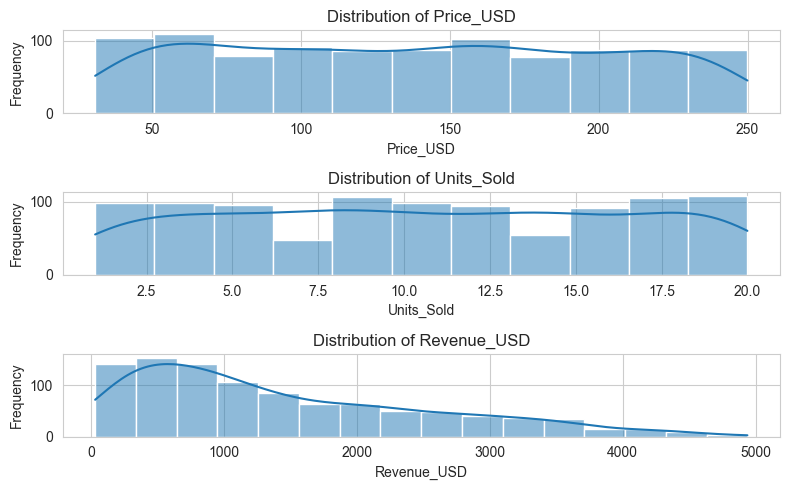

In [24]:
# histograms for numerical
numerical_cols= ['Price_USD', 'Units_Sold', 'Revenue_USD']

# for col in numerical_cols:

plt.figure(figsize=(8, 5)) # 8 is width and 5 is height
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 1, i)
    sns.histplot(data= df, x= col, kde= True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Count Plots for Categorical Features

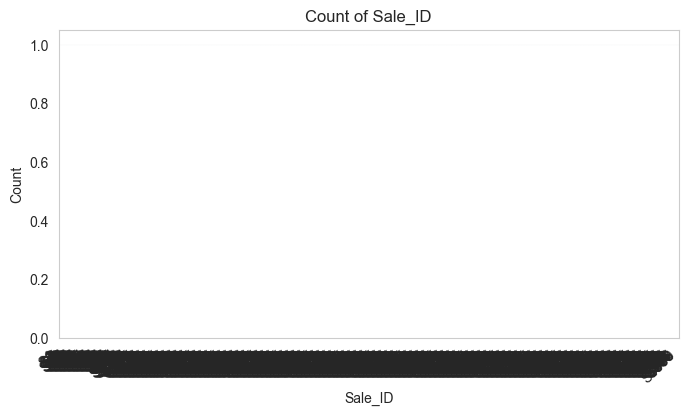

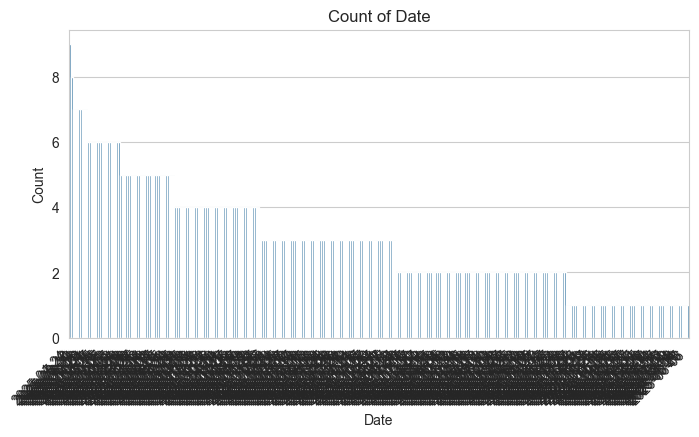

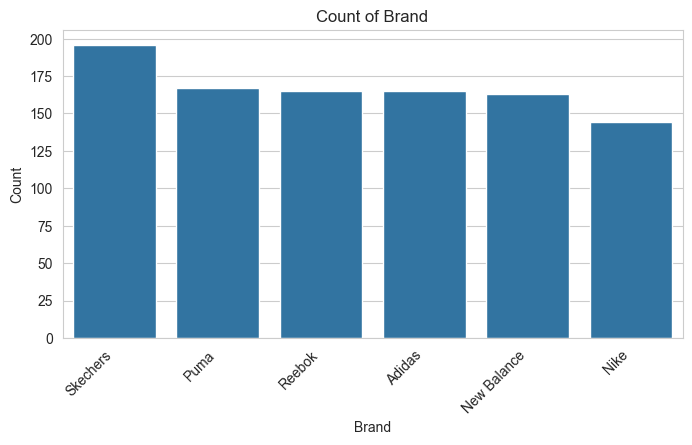

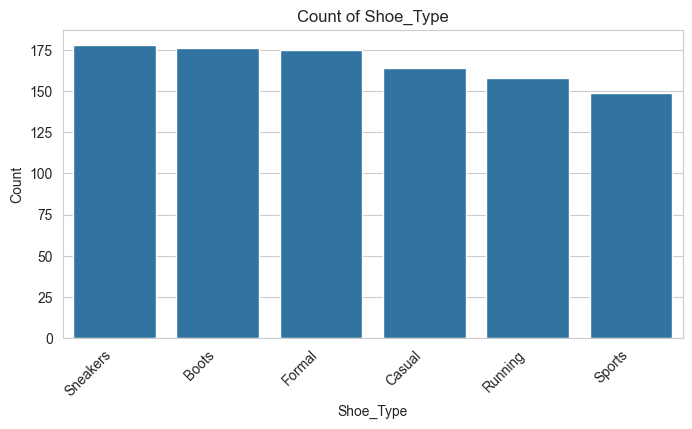

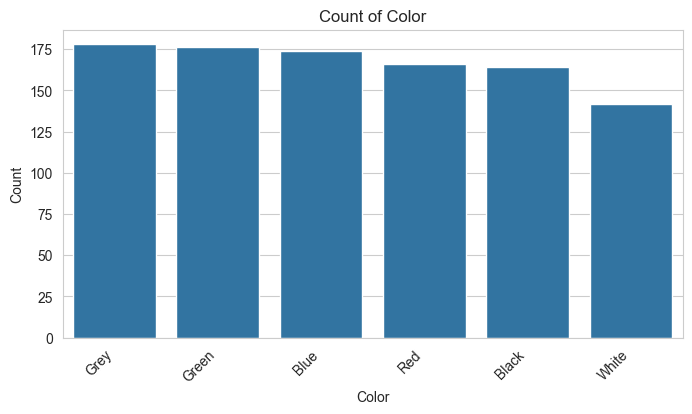

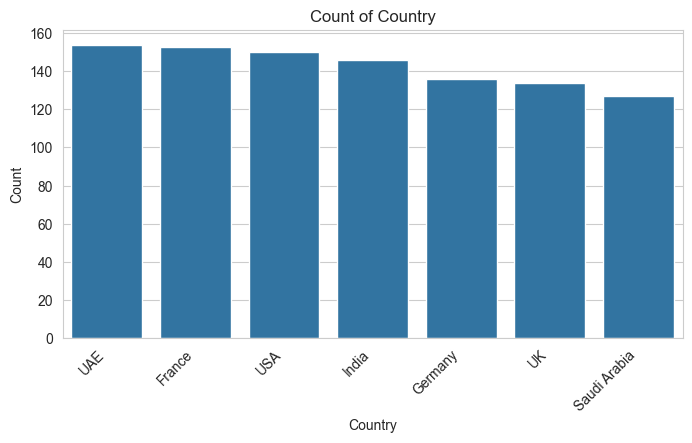

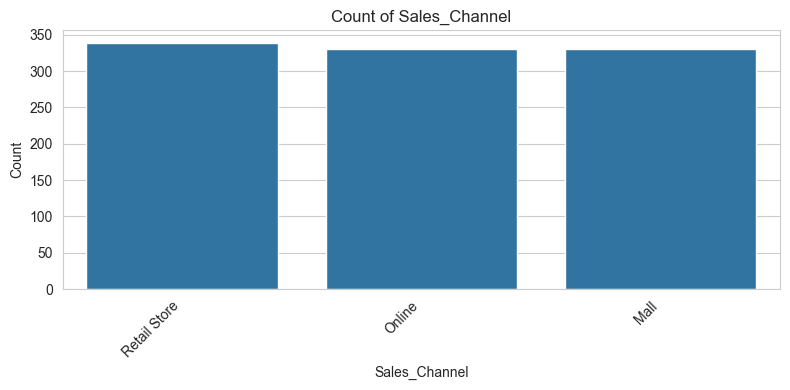

In [27]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Identify Outliers using Boxplots

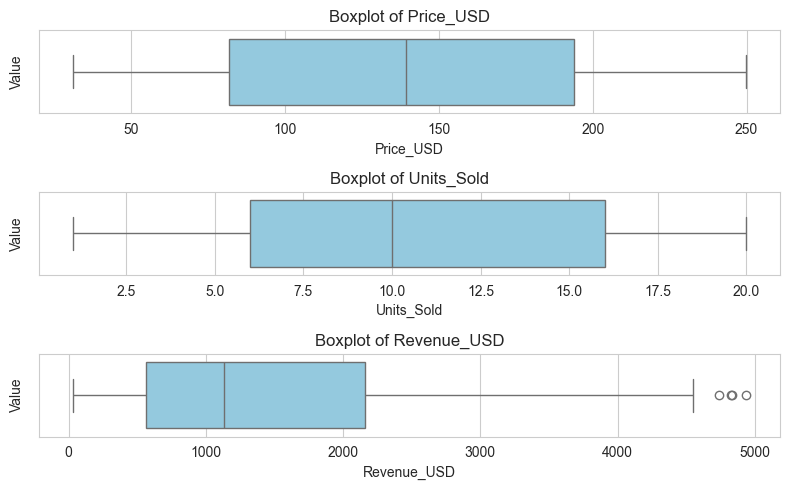

In [28]:
# Identify outliers using boxplots or IQR method.
numerical_cols= ['Price_USD', 'Units_Sold', 'Revenue_USD']

# for col in numerical_cols:
plt.figure(figsize=(8, 5)) # 15 is width and 10 is height
for i, col in enumerate(numerical_cols, 1): # give index and column
    plt.subplot(3, 1, i) # figure in 3*3 Matrix
        # plt.figure(figsize= (8, 4))
    sns.boxplot(data=df, x=col, color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.ylabel('Value')
plt.tight_layout()
plt.show()




### Bivariate Analysis

In [ ]:
df

In [ ]:
# Example: Scatter plot of Price_USD vs Revenue_USD
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Price_USD', y='Revenue_USD', hue='Brand', style='Shoe_Type' )
plt.title('Price vs. Revenue by Brand and Shoe_Type')
plt.xlabel('Price (USD)')
plt.ylabel('Revenue (USD)')
plt.grid(True)
plt.show()

# Example: Groupby comparison of Revenue_USD by Brand
brand_revenue = df.groupby('Brand')['Revenue_USD'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=brand_revenue.index, y=brand_revenue.values, palette='viridis')
plt.title('Total Revenue by Brand')
plt.xlabel('Brand')
plt.ylabel('Total Revenue (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Correlation Matrix

In [ ]:
# Create correlation matrix to find relationships between variables.

In [ ]:
# Create correlation matrix
# df.corr
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

### Summarize key insights and patterns for business understanding.

In [ ]:
# Summary of Key Insights and Patterns for Business Understanding
df.describe()  # statical summary


In [ ]:
df.info()

In [ ]:
df.isnull().sum() # check total null value

In [ ]:
df.dropna() # drop null value

In [ ]:
df

In [ ]:
df.groupby('Brand')['Units_Sold'].sum().sort_values(ascending=False)

#### key Insights:

#### Important insights from the shoe sales dataset include:

1. Dataset Structure Dataset contains sales informaton for various shoe brands, types, and sizes, along with pricing and revenue details.
2. Revenue trends Revenue strongly correlates with price, indicating higher-priced shoes generate more revenue.
3. Brand Performance some brands generate significantly higher revenue than others, premium brands tend to perform better.
4. Sales Channel Analysis Online sales outperform in-store sales, suggesting a shift towards e-commerce.
5. Outliers a few transactions show unusually high revenue, likely due to bulk purchases or premium products, which may require further investigation.
6. Correlation Analysis Revenue has positive correlation with price and units sold, while price and units sold show a weaker correlation, indicating that higher prices may not always lead to more sales.


#### final Conclusions:
Based on the analysis of the shoe sales dataset, we can conclude that:

Understanding dataset structure Cleaning and preprocessing data detecting outlier and duplicates Exploring numerical and categorical features finding relationships between variables and summarizing key insights are crucial steps in data analysis. 

#### The dataset is suitable for:
1. Sales Performance Analysis: Evaluating revenue trends and brand performance.
2. Customer Behavior Analysis: Understanding purchasing patterns and preferences.


#### Thank You!
